# Exploratory Data Analysis (EDA)

## Business Problem

Burger sales are believed to be influenced by weather conditions such as temperature, humidity, wind, visibility, and pressure.

The objective of this notebook is to understand the data through visualization and statistical analysis before developing forecasting models.

---

## Objectives

- Understand the sales distribution.
- Analyze weather variables.
- Compare sales across regions.
- Identify trends and anomalies.
- Investigate relationships between weather and sales.
- Generate insights that will improve predictive modeling.

In [44]:
# ==========================================================
# Exploratory Data Analysis
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Makes plots appear inside Jupyter Notebook
%matplotlib inline

# Improve notebook appearance
plt.style.use("ggplot")

# Display options
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [45]:
# ==========================================================
# Load Clean Dataset
# ==========================================================

df = pd.read_csv("../data/burger_data_clean.csv")

# Convert Date back to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Date,Region,Temperature,Humidity,Wind,Visibility,Pressure,Sales
0,2014-01-01,Reg1,17.471199,0.753878,6.755839,13.807525,1014.437661,1539.45
1,2014-01-01,Reg1,17.471199,0.753878,6.755839,13.807525,1014.437661,1539.45
2,2014-01-02,Reg1,15.486660,0.957388,0.503180,5.949232,1012.246198,2205.38
3,2014-01-03,Reg1,7.495190,0.816925,5.716267,9.644521,1024.722764,405.83
4,2014-01-04,Reg1,8.621881,0.952650,5.801921,15.760321,1016.718063,3200.50


In [46]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names")

for column in df.columns:
    print(f"• {column}")

DATASET OVERVIEW
Rows    : 24452
Columns : 8

Column Names
• Date
• Region
• Temperature
• Humidity
• Wind
• Visibility
• Pressure
• Sales


Instead of showing variables across the top, .T (transpose) puts each feature on its own row, making the table much easier to read.

In [47]:
# ==========================================================
# Summary Statistics
# ==========================================================

summary = df.describe().T

summary

,count,mean,min,25%,50%,75%,max,std
Date,24452,2017-05-09 08:07:19.326026496,2014-01-01 00:00:00,2015-09-05 00:00:00,2017-05-10 00:00:00,2019-01-12 00:00:00,2020-09-15 00:00:00,NaN
Temperature,24452.0,13.077983,-7.170076,4.339098,13.964321,21.806907,33.538482,9.570377
Humidity,24452.0,0.718637,0.0,0.547674,0.73411,0.902635,0.999396,0.199502
Wind,24452.0,10.697089,0.0,5.420347,9.413059,14.989989,36.206303,6.744509
Visibility,24452.0,9.995832,0.0,6.852248,10.556258,13.603445,16.093742,4.180311
Pressure,24452.0,1004.823749,0.0,1012.520668,1016.468088,1020.80826,1032.238678,92.072023
Sales,24452.0,1873.49637,0.16,846.5425,2026.07,2894.3925,3564.54,1085.70014


In [48]:
# ==========================================================
# Missing Values
# ==========================================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
Date,0,0.0
Region,0,0.0
Temperature,0,0.0
Humidity,0,0.0
Wind,0,0.0
Visibility,0,0.0
Pressure,0,0.0
Sales,0,0.0


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/figures/sales_distribution.png'

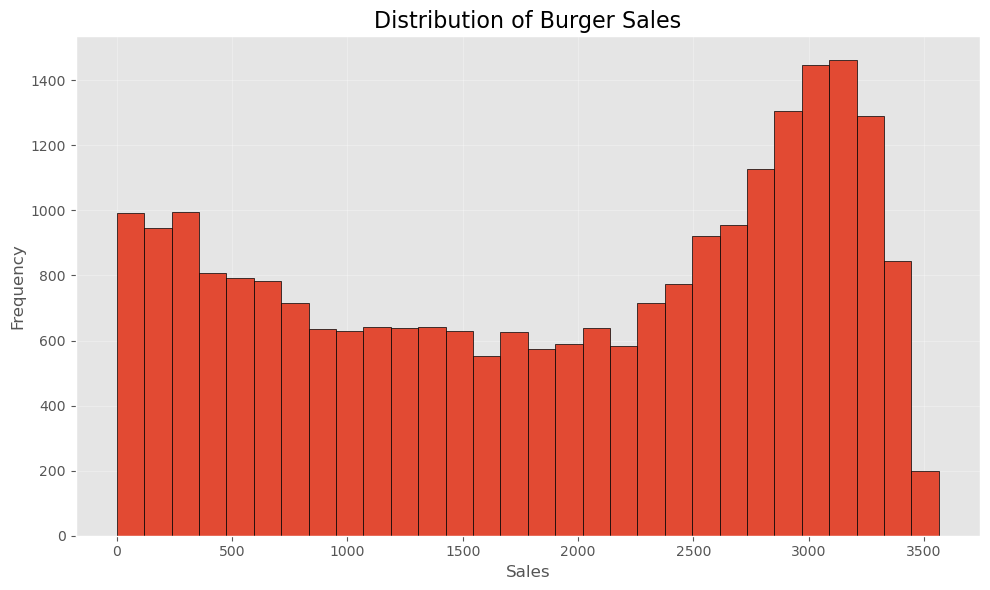

In [ ]:
# ==========================================================
# Distribution of Burger Sales
# ==========================================================

from pathlib import Path

# Ensure output directory exists
Path("../outputs/figures").mkdir(parents=True, exist_ok=True)

# Create a figure
plt.figure(figsize=(10, 6))

# Plot histogram
plt.hist(
    df[column],
    bins=30,
    edgecolor="black"
)

# Add titles
plt.title("Distribution of Burger Sales", fontsize=16)

plt.xlabel("Sales", fontsize=12)

plt.ylabel("Frequency", fontsize=12)

# Add grid
plt.grid(alpha=0.3)

# Tight layout
plt.tight_layout()

# Save the figure
plt.savefig("../outputs/figures/sales_distribution.png", dpi=300)

# Display
plt.show()